### Amazon Fruits Dataset

## Task 1: Data Understanding and Visualization

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/Copy of FruitinAmazon.zip'
extraction_path = './'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' unzipped to '{extraction_path}' successfully.")
print(f"Contents of the extraction directory: {os.listdir(extraction_path)}")

'/content/drive/MyDrive/Copy of FruitinAmazon.zip' unzipped to './' successfully.
Contents of the extraction directory: ['.config', 'drive', 'FruitinAmazon', 'cnn_fruits_model.h5', 'best_model.h5', 'sample_data']


In [20]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image
from sklearn.metrics import classification_report


train_dir = '/content/FruitinAmazon/train'
test_dir  = '/content/FruitinAmazon/test'
# setting dataset paths for training and testing

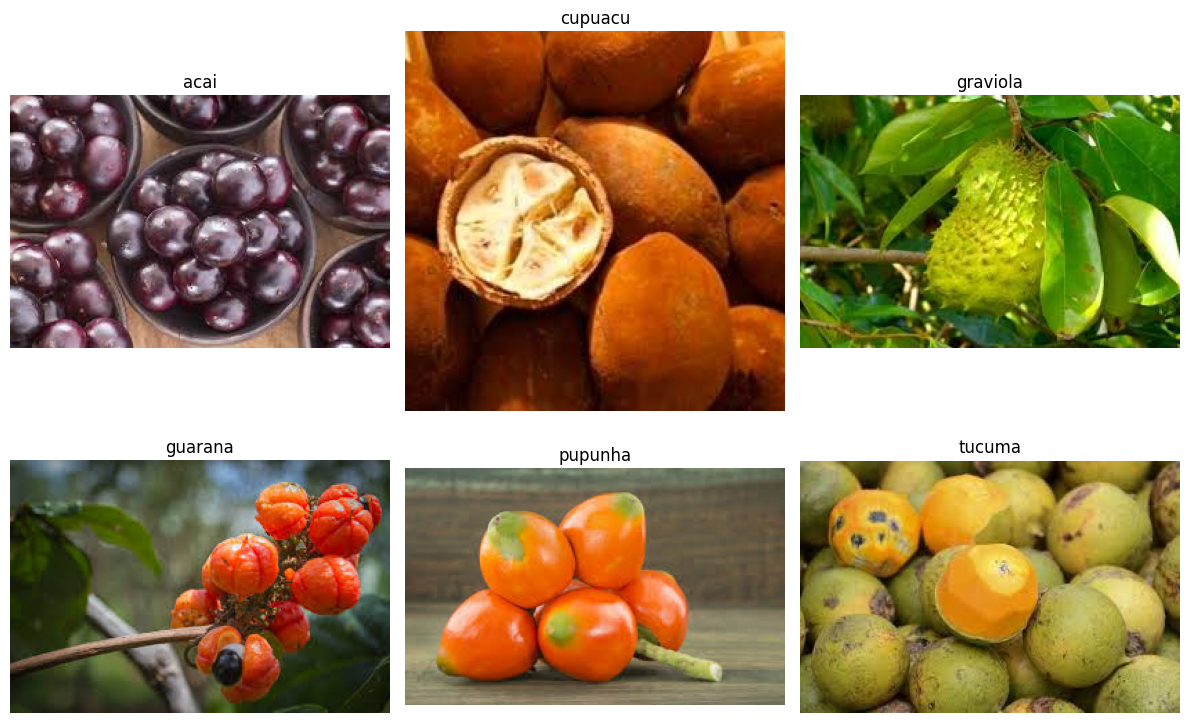

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Observation: Images vary in size, background, and lighting across classes.


In [21]:
# Task 1.1 - Visualise one random image per class in a 2-row grid

class_dirs = sorted(os.listdir(train_dir))
num_classes = len(class_dirs)
# reading all class folders and counting total classes

cols = (num_classes + 1) // 2
fig, axes = plt.subplots(2, cols, figsize=(cols * 4, 8))
axes = axes.flatten()
# creating a 2-row grid dynamically based on number of classes

for i, cls in enumerate(class_dirs):
    cls_path = os.path.join(train_dir, cls)
    images = os.listdir(cls_path)

    img_path = os.path.join(cls_path, random.choice(images))
    # picking one random image from each class

    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')
    # displaying image with class name

for j in range(i + 1, len(axes)):
    axes[j].axis('off')
# hiding extra empty plots if any

plt.tight_layout()
plt.show()

print(f"Classes found: {class_dirs}")
print("Observation: Images vary in size, background, and lighting across classes.")
# noting variation in dataset which may affect model learning

In [22]:
# Task 1.2 - Check for and remove corrupted images

corrupted = []
# list to track corrupted image paths

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)

    for fname in os.listdir(cls_path):
        img_path = os.path.join(cls_path, fname)

        try:
            img = Image.open(img_path)
            img.verify()
            # verify checks if image file is readable and not broken

        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            # removing corrupted image to avoid training issues

            print(f"Removed corrupted image: {img_path}")

if not corrupted:
    print("No Corrupted Images Found.")
# confirming dataset is clean

No Corrupted Images Found.


## Task 2: Loading and Preprocessing Image Data

In [23]:
# Hyperparameters
img_height      = 128
img_width       = 128
batch_size      = 16
validation_split = 0.2
# setting image size, batch size, and validation split

# Normalise pixel values to [0, 1]
rescale = tf.keras.layers.Rescaling(1./255)
# scaling pixel values for stable training

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)
# loading training data with automatic label assignment

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
# applying normalization to images


# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)
# splitting validation data from same directory

val_ds = val_ds.map(lambda x, y: (rescale(x), y))
# applying same normalization


# Test dataset (no split, full folder)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)
# loading full test dataset separately

test_ds = test_ds.map(lambda x, y: (rescale(x), y))
# normalizing test data as well


print(f"Number of classes: {num_classes}")
# quick check for total number of classes

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Number of classes: 6


## Task 3: Build the CNN Model

In [24]:
# CNN architecture
model = keras.Sequential([

    # Conv Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                  input_shape=(img_height, img_width, 3)),
    # extracting basic features like edges, colors

    layers.MaxPooling2D((2, 2), strides=2),
    # reducing spatial size → keeps important features

    # Conv Block 2
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    # learning slightly more complex patterns

    layers.MaxPooling2D((2, 2), strides=2),
    # further downsampling

    # Flatten and fully connected layers
    layers.Flatten(),
    # converting feature maps → 1D vector

    layers.Dense(128, activation='relu'),
    # learning higher-level representations

    layers.Dense(64, activation='relu'),
    # refining features before output

    # Output layer
    layers.Dense(num_classes, activation='softmax')
    # final probabilities for each class
])

model.summary()
# overview of layers and parameters

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Compile and Train the Model

In [25]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
# Callbacks: save best model and stop early if no improvement

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
# saves only the best-performing model based on validation accuracy

early_stop_cb = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)
# stops training if validation loss doesn’t improve for 15 epochs
# restores best weights instead of last ones


history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb]
)
# training the model with validation monitoring and callbacks applied

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.1788 - loss: 2.1628
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 349ms/step - accuracy: 0.1806 - loss: 2.1790 - val_accuracy: 0.0000e+00 - val_loss: 2.2209
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.3729 - loss: 1.5546
Epoch 2: val_accuracy improved from 0.00000 to 0.38889, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 312ms/step - accuracy: 0.4167 - loss: 1.5085 - val_accuracy: 0.3889 - val_loss: 1.3512
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.5271 - loss: 1.2899
Epoch 3: val_accuracy improved from 0.38889 to 0.72222, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 404ms/step - accuracy: 0.5000 - loss: 1.2119 - val_accuracy: 0.7222 - val_loss: 1.2861
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.6858 - loss: 1.0273
Epoch 4: val_accuracy did not improve from 0.72222
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 481ms/step - accuracy: 0.6944 - loss: 1.0103 - val_accuracy: 0.5000 - val_loss: 1.2910
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.8872 - loss: 0.6753
Epoch 5: val_accuracy did not improve from 0.72222
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 337ms/step - accuracy: 0.8889 - loss: 0.6765 - val_accuracy: 0.7222 - val_loss: 0.8284
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.8677 - loss: 0.5658
Epoch 6: val_accuracy improved from 0.72222 to 0.88889, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 316ms/step - accuracy: 0.8750 - loss: 0.5383 - val_accuracy: 0.8889 - val_loss: 0.6814
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.9882 - loss: 0.2850
Epoch 7: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step - accuracy: 0.9722 - loss: 0.3184 - val_accuracy: 0.7222 - val_loss: 0.6096
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.9722 - loss: 0.1664
Epoch 8: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 284ms/step - accuracy: 0.9444 - loss: 0.1905 - val_accuracy: 0.8333 - val_loss: 0.5804
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9323 - loss: 0.1657
Epoch 9: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 289ms/step - accuracy: 0.9583 - loss: 0.1398 - val_accuracy: 0.8333 - val_loss: 0.3699
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 1.0000 - loss: 0.08


Epoch 11: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 529ms/step - accuracy: 1.0000 - loss: 0.0350 - val_accuracy: 0.9444 - val_loss: 0.2788
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 1.0000 - loss: 0.0200
Epoch 12: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 283ms/step - accuracy: 1.0000 - loss: 0.0185 - val_accuracy: 0.8889 - val_loss: 0.2733
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 1.0000 - loss: 0.0134
Epoch 13: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 285ms/step - accuracy: 1.0000 - loss: 0.0120 - val_accuracy: 0.8889 - val_loss: 0.2392
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 1.0000 - loss: 0.0100
Epoch 14: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 279ms/step - accuracy: 1.0000 - loss: 0.0072 - val_accuracy: 0.9444 - val_loss: 0.2057
Epoch 15/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 1.0000 - los

## Visualisation: Training & Validation Loss/Accuracy

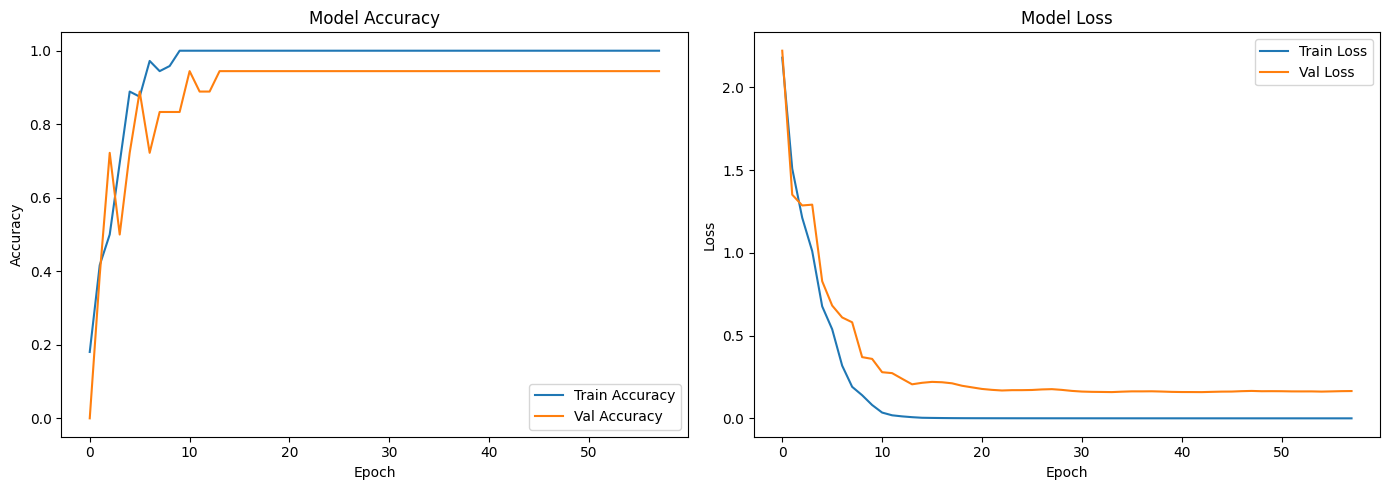

In [27]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
# checking how accuracy evolves for both train and validation

axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
# observing loss trend to detect overfitting or underfitting

axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


## Task 5: Evaluate the Model

In [28]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6333 - loss: 1.5689
Test Loss:     1.5689
Test Accuracy: 0.6333


## Task 6: Save and Load the Model

In [29]:
# Save model
model.save('cnn_fruits_model.h5')
# saving trained CNN model for reuse

print("Model saved as cnn_fruits_model.h5")


# Load and re-evaluate to confirm it saved correctly
loaded_model = keras.models.load_model('cnn_fruits_model.h5')
# loading saved model

loss, acc = loaded_model.evaluate(test_ds)
# evaluating on test dataset

print(f"Loaded Model - Test Loss: {loss:.4f} | Test Accuracy: {acc:.4f}")

Model saved as cnn_fruits_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6333 - loss: 1.5689
Loaded Model - Test Loss: 1.5689 | Test Accuracy: 0.6333


## Task 7: Predictions and Classification Report

In [30]:
# Collect all true labels and predictions from test set
y_true, y_pred = [], []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    # predicting batch-wise

    y_pred.extend(np.argmax(preds, axis=1))
    # converting probabilities → predicted labels

    y_true.extend(labels.numpy())
    # storing actual labels

print(classification_report(y_true, y_pred, target_names=class_dirs))
# detailed performance metrics (precision, recall, f1-score per class)

              precision    recall  f1-score   support

        acai       0.57      0.80      0.67         5
     cupuacu       0.44      0.80      0.57         5
    graviola       0.83      1.00      0.91         5
     guarana       0.50      0.40      0.44         5
     pupunha       1.00      0.40      0.57         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.63        30
   macro avg       0.72      0.63      0.62        30
weighted avg       0.72      0.63      0.62        30

